# Topic modelling 

This workbook implements topic modelling - and explores some different model parameters and approaches. 

It first pre-processes the text. This first consists of performing named entity recognition (NER) - utilising the pre-trained HuggingFace model ([reddit-ner-place-names](https://huggingface.co/cjber/reddit-ner-place_names) developed by Cillian Berragan at Liverpool uni. 

I then look at using BERTopic to identify clusters of topics. 

Then I consider alternative models. These require further text pre-processing including the removal of stop words, removal of punctuation and lemmatization of the text. The alternative models I consider are: 
* Latent dirichlet allocation (LDA)
* Latent semantic analysis (LSA)

In [1]:
import pandas as pd
import numpy as np
import re
import string 
from datasets import Dataset

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from scipy.cluster import hierarchy as sch

from transformers import AutoModelForMaskedLM, pipeline, AutoTokenizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired

import nltk 
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from gensim import corpora
from gensim.models import LdaModel

from hdbscan import HDBSCAN
from umap import UMAP

import sys
sys.path.append('../pipeline')
from nlp_tasks import NLP_Tasks
from comments_saver import CommentsSaver

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /Users/bea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/bea/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/bea/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Start by loading the data - this is a small chunk of data which has been scraped. 

In [2]:
# Load data
train_df = pd.read_csv('../outputs/train_comments.csv')
test_df = pd.read_csv('../outputs/test_comments.csv')

# Convert DataFrame to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [3]:
print(f'Number of comments in training dataset: {len(train_dataset)} \nNumber of comments in test dataset: {len(test_dataset)}')

Number of comments in training dataset: 542 
Number of comments in test dataset: 136


In [4]:
text = list(train_df['comment_text'])

In [ ]:
# model_checkpoint = "distilbert-base-uncased"
model_checkpoint = "../outputs/nlp_fine_tuning/distilbert-base-uncased"
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

## Chunking - approaches to limit the number of tokens

Split the text in various ways to parse ins smaller formats. But first, visualise the distribution of token length.

In [6]:
def tokenize_function(examples):
    result = tokenizer(examples["comment_text"])
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result

tokenized_datasets = train_dataset.map(tokenize_function, batched=True, remove_columns=["address", "stance", "date", "comment_text"])

Map: 100%|██████████| 542/542 [00:00<00:00, 4331.94 examples/s]


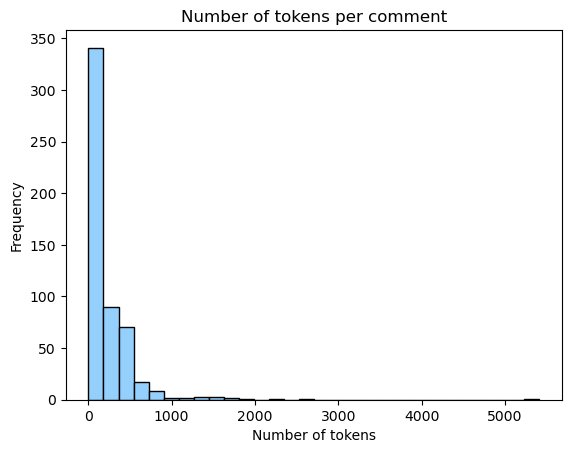

In [7]:
# Extract the number of tokens for each item in tokenized_datasets
num_tokens = [len(item["input_ids"]) for item in tokenized_datasets]

# Plot the histogram
plt.hist(num_tokens, bins=30, color='xkcd:light blue', edgecolor='black')
plt.title("Number of tokens per comment")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

Now for the chunking - split the chunks according to line-down, which is denoted by '\n' in HTML.

In [8]:
# some pre-processing 
text = [sentence.split('\n') for sentence in text]
text = [item for sublist in text for item in sublist]
text = [sentence.replace('\n', '') for sentence in text]

# remove empty strings from the list
text = list(filter(None, text))

In [9]:
print(f'Number of chunked comments in training dataset: {len(text)}')

Number of chunked comments in training dataset: 2508


Visualise the distribution of tokens in the freshly chunked data.

Map: 100%|██████████| 2508/2508 [00:00<00:00, 23086.04 examples/s]


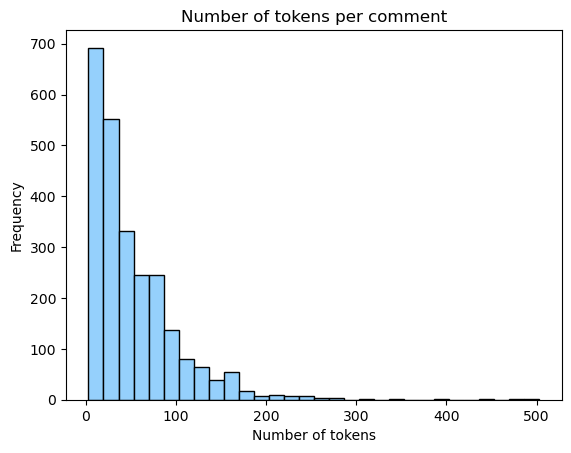

In [10]:
chunk_text = Dataset.from_dict({'comment_text':text})

# Use batched=True to activate fast multithreading!
chunk_text = chunk_text.map(tokenize_function, batched=True)

# Extract the number of tokens for each item in tokenized_datasets
num_tokens = [len(item["input_ids"]) for item in chunk_text]

# Plot the histogram
plt.hist(num_tokens, bins=30, color='xkcd:light blue', edgecolor='black')
plt.title("Number of tokens per comment")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

In [11]:
max_length_tokens = 300 #512
min_length_tokens = 5

num_long_chunks = sum(len(item["input_ids"]) > max_length_tokens for item in chunk_text)
print(f"Number of items with tokens > {max_length_tokens}: {num_long_chunks}")

num_short_chunks = sum(len(item["input_ids"]) < min_length_tokens for item in chunk_text)
print(f"Number of items with tokens < {min_length_tokens}: {num_short_chunks}")

Number of items with tokens > 300: 9
Number of items with tokens < 5: 84


In [12]:
# Find indices of items with input_ids length greater than max_length_tokens
below_indices = [i for i, item in enumerate(chunk_text) if len(item["input_ids"]) < 4]

# Print the comment_text for those indices
for idx in below_indices[:10]:  # Print only the first 10 for brevity
    print(f"Index: {idx}, Comment Text: {chunk_text['comment_text'][idx]}")

Index: 248, Comment Text: Consultation
Index: 256, Comment Text: Policies
Index: 267, Comment Text: Design
Index: 285, Comment Text: Housing
Index: 306, Comment Text: Conclusions
Index: 344, Comment Text: Shocked
Index: 371, Comment Text: Object
Index: 393, Comment Text: Thanks
Index: 823, Comment Text: yours
Index: 854, Comment Text: Regards


In [13]:
# Remove items at indices in below_indices
text = [text[i] for i in range(len(text)) if i not in below_indices]

## Baseline topic modelling acheived with BertTopic and minimal pre-processing 

This uses the pretrained domain knowledge model which was an output of 1_0_1_domain_knowledge_nlp.ipynb

In [14]:
topic_model = BERTopic(embedding_model=model)
topics, probs = topic_model.fit_transform(text)

topic_model.get_topic_info()[:10]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,588,-1_of_the_and_to,"[of, the, and, to, this, in, for, is, communit...",[I have previously commented on this new propo...
1,0,141,0_sunlight_privacy_daylight_building,"[sunlight, privacy, daylight, building, light,...","[Unsurprisingly, there is also a significant e..."
2,1,136,1_wharf_royal_green_the,"[wharf, royal, green, the, this, already, in, ...",[The area is already getting very crowded with...
3,2,93,2_community_space_reduction_for,"[community, space, reduction, for, groups, use...","[Third, the significant reduction of community..."
4,3,81,3_school_next_nursery_primary,"[school, next, nursery, primary, noise, constr...","[Construction noise, dust and disruption. The ..."
5,4,79,4_ballymore_green_space_wharf,"[ballymore, green, space, wharf, this, royal, ...",[Loss of amenity. Owners at Royal Wharf were s...
6,5,76,5_green_space_more_was,"[green, space, more, was, development, area, s...",[This should be a green space as advertised at...
7,6,70,6_height_street_high_is,"[height, street, high, is, design, the, area, ...","[I strongly object to the proposals. First, th..."
8,7,57,7_parking_car_spaces_already,"[parking, car, spaces, already, cars, insuffic...",[Insufficient provision of car parking. As par...
9,8,52,8_noise_plant_acoustic_vibration,"[noise, plant, acoustic, vibration, 00, levels...",[Where the proposed residential use is in a bu...


## Removing geographic place names using named entity recognition 
I don't want the topics identified to relate to the place names of specific applications (i.e. Durning Hall or Forest Gate) - as I want the topics to be generalised themes, common across applications - hence I remove all place names. This uses Named Entity Recognition (NER), I intially tried using the out of the box bog-standard model, but it wasn't able to recognise more specific British place names. Instead I use the "cjber/reddit-ner-place_names" - which has specifically been trained to recognise these sorts of place names. 

```
ner_pipeline = pipeline(
    task="ner",
    model="cjber/reddit-ner-place_names",
    tokenizer="cjber/reddit-ner-place_names",
    aggregation_strategy="first",
)


Call some pre-processing functions from nlp_tasks.py that format the data.

In [15]:
nlp = NLP_Tasks(model_checkpoint)

# remove place names
train_df = nlp.remove_place_names(df=train_df, column='comment_text')
# remove stop words
train_df = nlp.remove_numbers(df=train_df, column='cleaned_comment_text')
# remove non-ASCII characters
train_df = nlp.remove_non_ascii(df=train_df, column='cleaned_comment_text')

# split text on newlines, this function preserves the metadata by exploding the dataframe
train_df_split = nlp.split_text_on_newline(df=train_df, column='cleaned_comment_text')

Device set to use mps:0


In [16]:
cleaned_place_text = train_df_split['cleaned_comment_text'].tolist()

### Repeat BertTopic modelling with geographic place names removed 

This uses the same fine-tuned huggingface transformer model fine-tuned to have domain specific knowledge from earlier. But, I have done some additional data processing, and I specify some of the models hyper parameters. 

In [17]:
# this controls the seed - allowing for reproducible maps 
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=43)

# this controls the topic parameters
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

In [18]:
topic_model_no_place = BERTopic(embedding_model=model, hdbscan_model=hdbscan_model, umap_model=umap_model, verbose=True, calculate_probabilities=True)
topics, probs = topic_model_no_place.fit_transform(cleaned_place_text)

topic_model_no_place.get_topic_info()[:10]

2025-04-15 11:11:09,537 - BERTopic - Embedding - Transforming documents to embeddings.


Batches: 100%|██████████| 78/78 [00:42<00:00,  1.85it/s]
2025-04-15 11:11:54,388 - BERTopic - Embedding - Completed ✓
2025-04-15 11:11:54,388 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-15 11:12:01,510 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:12:01,511 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-15 11:12:01,716 - BERTopic - Cluster - Completed ✓
2025-04-15 11:12:01,718 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-04-15 11:12:01,789 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,521,-1_and_the_of_to,"[and, the, of, to, this, in, is, for, developm...",[) It is planned to access the development thr...
1,0,318,0_community_space_for_to,"[community, space, for, to, that, hall, and, i...","[When our School first opened, Durning Hall wa..."
2,1,197,1_green_space_was_this,"[green, space, was, this, would, the, of, in, ...",[Loss of amenity. Owners at were sold on the s...
3,2,126,2_school_nursery_next_children,"[school, nursery, next, children, construction...","[The noise, traffic, dust and construction wil..."
4,3,118,3_sunlight_daylight_privacy_building,"[sunlight, daylight, privacy, building, light,...","[Unsurprisingly, there is also a significant e..."
5,4,106,4_height_high_street_the,"[height, high, street, the, area, of, keeping,...","[I strongly object to the proposals. First, th..."
6,5,69,5_parking_car_already_spaces,"[parking, car, already, spaces, units, bays, r...",[Insufficient provision of car parking. As par...
7,6,58,6_dlr_already_amenities_services,"[dlr, already, amenities, services, bus, servi...","[Since I have moved to in , I have seen the lo..."
8,7,52,7_noise_plant_acoustic_db,"[noise, plant, acoustic, db, vibration, levels...",[Where the proposed residential use is in a bu...
9,8,48,8_subject_planning_water_use,"[subject, planning, water, use, should, resolv...",[) The planning application submitted suggests...


Save the model using PyTorch 

In [19]:
# Save the topic model 
bertopic_model_dir = '/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_crunch/outputs/bertopic_fine_tuning'
topic_model_no_place.save(bertopic_model_dir, serialization="pytorch", save_ctfidf=True, save_embedding_model=model)

In [20]:
# Load the topic model
loaded_topic_model_no_place = BERTopic.load(bertopic_model_dir, embedding_model=model)

Some further analysis of the topic information

In [21]:
def print_topic_info(n):
    freq = topic_model_no_place.get_topic_freq(n)
    print(f'Frequency of the topic in the training dataset: {freq}\n')
    print(f'Representative documents of the topic:\n')
    print(f'{topic_model_no_place.get_representative_docs(n)[0]}')
    # for rep in topic_model_no_place.get_representative_docs(n):
    #     print(rep)

In [22]:
print_topic_info(1)

Frequency of the topic in the training dataset: 197

Representative documents of the topic:

Loss of amenity. Owners at were sold on the significant green space that would form part of the development. Approved planning applications for the development previously emphasised the amount of green space. now intend to take this away, having misled leaseholders into believing it would remain green space.


In [23]:
# `topic_distr` contains the distribution of topics in each document
topic_distr, _ = topic_model_no_place.approximate_distribution(cleaned_place_text, window=8, stride=4)

100%|██████████| 3/3 [00:00<00:00, 20.95it/s]


In [24]:
topic_model_no_place.visualize_topics()

In [25]:
topic_model_no_place.visualize_heatmap()

In [26]:
# Hierarchical topics
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model_no_place.hierarchical_topics(cleaned_place_text, linkage_function=linkage_function)

100%|██████████| 45/45 [00:00<00:00, 614.03it/s]


In [27]:
topic_model_no_place.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

### Out of set model performance 

Above I looked at identifying all topics for my training dataset. So what if I now try to assign these topics to a smaller subset - here all the comments relating to a single planning application. 

The planning applications considered:
* Ealing 223203FUL

In [28]:
cs = CommentsSaver(env='prod')
df = cs.read_all()
df_ealing = df[df['application_id']=='223203FUL']

Connecting to the ai4ci-db database...
Successfully connected to ai4ci-db.


In [29]:
df_ealing.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date
9638,9457,Ealing,223203FUL_112,223203FUL,34 lexden road london w3 9nz London W3 9NZ W3 9NZ,Objects,2022-08-25,Taking away trees .enough of highrise flats in...,2025-03-21
9648,9355,Ealing,223203FUL_21,223203FUL,10 Baldwyn Gardens London W3 6HH W3 6HH,Objects,2022-09-16,Yet another attempt by developers to push thro...,2025-03-21
9702,9332,Ealing,223203FUL_16,223203FUL,35 Cumberland Park London w3 6sx w3 6sx,Objects,2022-09-16,The proposals will not only be an eyesore and ...,2025-03-21
9705,9371,Ealing,223203FUL_35,223203FUL,34 Derwentwater Road LONDON W3 6DF W3 6DF,Objects,2022-09-10,The centre of Acton is overcrowded. The new bl...,2025-03-21
9707,9336,Ealing,223203FUL_1,223203FUL,177 Horn Lane Flat 2 London W3 6PW W3 6PW,Neutral,2022-10-09,In the shrubs next to the road you can find sh...,2025-03-21


In [30]:
print(f'Number of comments for application 223203FUL in Ealing: {len(df_ealing)}')

Number of comments for application 223203FUL in Ealing: 160


In [31]:
# remove place names, numbers and non-ASCII characters
df_ealing = nlp.remove_place_names(df=df_ealing, column='comment_text')
df_ealing = nlp.remove_numbers(df=df_ealing, column='cleaned_comment_text')
df_ealing = nlp.remove_non_ascii(df=df_ealing, column='cleaned_comment_text')

# # split text on newlines
df_ealing_split = nlp.split_text_on_newline(df=df_ealing, column='cleaned_comment_text')

In [32]:
cleaned_ealing_text = df_ealing_split['cleaned_comment_text'].tolist()

In [33]:
# Apply previous topic model to the new dataset of comments from the one application in Ealing 
topics_subset, probs_subset = topic_model_no_place.transform(cleaned_ealing_text)

Batches: 100%|██████████| 16/16 [00:06<00:00,  2.30it/s]
2025-04-15 11:14:16,233 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-04-15 11:14:18,852 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:14:18,852 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-04-15 11:14:18,863 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-04-15 11:14:18,912 - BERTopic - Probabilities - Completed ✓
2025-04-15 11:14:18,912 - BERTopic - Cluster - Completed ✓


In [ ]:
# # Get topic labels from BERTopic
# topic_info = topic_model_no_place.get_topic_info()
# topic_labels = [f"{row['Topic']}: {row['Representation'][:30]}" for _, row in topic_info.iterrows()]

# # Create figure and axis
# fig, ax = plt.subplots(figsize=(12, 6))

# # Display heatmap using imshow
# cax = ax.imshow(probs_array, cmap="Blues", aspect="auto")

# # Add colorbar
# fig.colorbar(cax, ax=ax, label="Probability")

# # Labels
# ax.set_xlabel("Topic")
# ax.set_ylabel("Text Entry")
# ax.set_title("Topic Probability Heatmap for subset_text")

# # Set x-axis tick labels
# ax.set_xticks(np.arange(len(topic_labels)))  # Set tick positions
# ax.set_xticklabels(topic_labels, rotation=90, ha="right")  # Set tick labels

# # Show plot
# plt.show()


In [ ]:
# # Identify topics with a probability > 0.5 in at least one entry
# selected_topics = np.where(probs_array > 0.5)[1]  # Get topic indices
# selected_topics = np.unique(selected_topics)  # Remove duplicates

# # Find the main topic (topic with highest probability) for each entry
# main_topics = np.argmax(probs_array, axis=1)  # Index of highest probability topic for each entry

# # Count occurrences of each main topic
# topic_counts = pd.Series(main_topics).value_counts().reset_index()
# topic_counts.columns = ["Topic", "Count"]

# # Get topic representations from BERTopic
# topic_info = topic_model_no_place.get_topic_info()

# # Filter topic_info to only include selected topics
# filtered_topics = topic_info[topic_info["Topic"].isin(selected_topics)][["Topic", "Representation"]]

# # Merge with topic counts
# final_topics = filtered_topics.merge(topic_counts, on="Topic", how="left").fillna(0)

# # Display the result
# print(final_topics)

Identify the frequency and probability of assignment across a range of different topics. 

In [36]:
# Convert probabilities to NumPy array
probs_array = np.array(probs_subset)

# Identify topics with a probability > 0.5 in at least one entry
selected_topics = np.where(probs_array > 0.5)[1]  
selected_topics = np.unique(selected_topics)  

# Find the main topic for each document
main_topics = np.argmax(probs_array, axis=1)

# Count occurrences of each main topic
topic_counts = pd.Series(main_topics).value_counts().reset_index()
topic_counts.columns = ["Topic", "Count"]

# Get topic representations from BERTopic (full version)
topic_info = topic_model_no_place.get_topic_info()
filtered_topics = topic_info[topic_info["Topic"].isin(selected_topics)][["Topic", "Representation"]]

# Merge with topic counts
final_topics = filtered_topics.merge(topic_counts, on="Topic", how="left").fillna(0)

# Get representative documents: Take 3 example documents for each topic
representative_docs = {}
for topic in selected_topics:
    doc_indices = np.where(main_topics == topic)[0]  # Get indices of docs assigned to this topic
    top_docs = [cleaned_ealing_text[i] for i in doc_indices[:3]]  # Get up to 3 docs
    representative_docs[topic] = top_docs

# Add representative documents to the dataframe
final_topics["Representative Docs"] = final_topics["Topic"].map(representative_docs)

# Display full data
pd.set_option("display.max_colwidth", None)  # Ensure full text is shown
final_topics

,Topic,Representation,Count,Representative Docs
0,0,"[community, space, for, to, that, hall, and, in, the, durning]",9,"[Transformation of footpath to a road - removing local community asset, Transformation of footpath to a road - removing local community asset, Transformation of footpath to a road - removing local community asset]"
1,1,"[green, space, was, this, would, the, of, in, development, as]",42,"[. Affecting ecology - Loss of mature trees and biodiversity. I note that the Bat report suggests that 'habitats supported on the site at provide no obvious roosting opportunities for bats'. I know this not to be true as our garden which backs onto the site has regular bat activity during twilight hours in the summer months. There are some beautiful trees on the site which not only aid the biodiversity of the area but are beneficial for the well bing of the residents. I believe that the council should be protecting these mature trees not taking them down., . Open space - the proposed increase in in residential properties, with resulting lack of open space is also of particular concern. In a post COVID world, planners should be creating developments with more open space not less., . Affecting ecology - Loss of mature trees and biodiversity. I note that the Bat report suggests that 'habitats supported on the site at provide no obvious roosting opportunities for bats'. I know this not to be true as our garden which backs onto the site has regular bat activity during twilight hours in the summer months. There are some beautiful trees on the site which not only aid the biodiversity of the area but are beneficial for the well bing of the residents. I believe that the council should be protecting these mature trees not taking them down.]"
2,2,"[school, nursery, next, children, construction, primary, and, noise, dust, building]",15,"[. Out of keeping with surrounding area, overbearing., I take my children swimming and to meet friends in , from south, and am disappointed to see more mature trees being removed to make space for yet another high rise building, which is out of keeping with local surroundings. Please reconsider this proposal. Thank you., . Out of keeping with surrounding area, overbearing.]"
3,3,"[sunlight, daylight, privacy, building, light, north, the, will, living, of]",44,"[This is outrageous. How on earth can you think this is fitting into the local area?, Loss of daylight, sunlight and privacy of neighbours, creates a loss of daylight, sunlight and privacy of neighbours]"
4,4,"[height, high, street, the, area, of, keeping, design, is, buildings]",58,"[Yet another attempt by developers to push through a totally unsuitable project in this area. These tall skyscrapers are totally out of keeping with the area, and only add more pressure to the already over-stretched infrastructure and services of . On top of that, the electrical power requirements of these developments will severely strain our services to breaking point. Fully object., . Over development and out of keeping - the plans as presented are completely out of keeping with the local area. While and are storeys, they are an anomaly in . While some sensitive development of the site and improvements for existing residents is surely welcome, buildings of this height and mass will dominate the local skyline, reduce light and amenity for neighbours and put a strain on existing local facilities. The council should be looking to build to a much lower height to better integrate the site with the surrounding area., . Over development and out of keeping - the plans as presented are completely out of keeping with the local area. While and are storeys, they are an anomaly in . While some sensitive development of the site and improvements for existing residents is surely welcome, buildings of this height and mass will dominate the local skyline, reduce light and amenity for neighbours and put a strain on existing local facilities. The council should be looking to build to a m

### See if there are comments relating to specific topics

From reading the committee report for Ealing application 223203FUL I know there should be comments specifcally relating to both the scale and density of the development. Let's see if I can force identification of these topics. 

First I try using a simple regex match. 

In [37]:
# Define keyword lists for each topic
scale_keywords = ["large-scale", "expansion", "size of development", "massive project", "extent", "scale"]
density_keywords = ["density", "overcrowding", "high-rise", "too many units", "population increase", "compact"]

# Search subset_text for keyword matches
scale_texts = [text for text in cleaned_ealing_text if any(word in text.lower() for word in scale_keywords)]
density_texts = [text for text in cleaned_ealing_text if any(word in text.lower() for word in density_keywords)]

# Print results
print(f"Texts related to 'Scale of the development': {len(scale_texts)}")
print(scale_texts[:5])  # Show first 5 examples

print(f"\nTexts related to 'Density of the development': {len(density_texts)}")
print(density_texts[:5])  # Show first 5 examples

Texts related to 'Scale of the development': 12
['Design/ Massing/ Scale:', "Although I am not totally against the development of additional buildings on the site, building 'A' is not in keeping. The overall massing is far greater than that of the existing towers. In addition, building 'A' sits directly adjacent the highway/  storey homes, something that does not relate to the exiting character. The building should be set back considerably further from the main road. From a townscape perspective, the overall massing and scale (footprint, height) should be reduced by at least % to make it anywhere near acceptable.", 'This scale of this project is not in keeping with the local landscape and minimal information about its management and maintenance has been provided.', 'Utility supply will be put under further pressure because of the massive scale of this planned development, especially electricity, water and sewage handing.', 'The proposed Block A will make this blight considerably worse,

In [38]:
# Step 1: Transform scale & density texts to get topic assignments
scale_topics, scale_probs = topic_model_no_place.transform(scale_texts)
density_topics, density_probs = topic_model_no_place.transform(density_texts)

# Step 2: Identify main topic (highest probability) for each text
scale_main_topics = np.argmax(scale_probs, axis=1)
density_main_topics = np.argmax(density_probs, axis=1)

# Step 3: Count occurrences of each topic
scale_topic_counts = pd.Series(scale_main_topics).value_counts().reset_index()
scale_topic_counts.columns = ["Topic", "Scale_Count"]

density_topic_counts = pd.Series(density_main_topics).value_counts().reset_index()
density_topic_counts.columns = ["Topic", "Density_Count"]

# Step 4: Get topic representations from BERTopic
topic_info = topic_model_no_place.get_topic_info()

# Step 5: Merge counts with topic representations
scale_topic_info = topic_info.merge(scale_topic_counts, on="Topic", how="inner")
density_topic_info = topic_info.merge(density_topic_counts, on="Topic", how="inner")

# Step 6: Display results
print("\nTopics most related to 'Scale of the development':")
print(scale_topic_info[["Representation", "Scale_Count"]].sort_values(by="Scale_Count", ascending=False))

print("\nTopics most related to 'Density of the development':")
print(density_topic_info[["Representation", "Density_Count"]].sort_values(by="Density_Count", ascending=False))


Batches: 100%|██████████| 1/1 [00:01<00:00,  1.38s/it]
2025-04-15 11:14:20,408 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-04-15 11:14:20,444 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:14:20,444 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-04-15 11:14:20,445 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-04-15 11:14:20,449 - BERTopic - Probabilities - Completed ✓
2025-04-15 11:14:20,449 - BERTopic - Cluster - Completed ✓
Batches: 100%|██████████| 2/2 [00:01<00:00,  1.10it/s]
2025-04-15 11:14:22,272 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-04-15 11:14:22,389 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:14:22,389 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-04-15 11:14:22,391 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-04-15 11:14:22,397 - BERTopic - Proba


Topics most related to 'Scale of the development':
                                                                         Representation  \
2                 [height, high, street, the, area, of, keeping, design, is, buildings]   
0                        [community, space, for, to, that, hall, and, in, the, durning]   
1                        [green, space, was, this, would, the, of, in, development, as]   
3         [dlr, already, amenities, services, bus, service, tfl, gym, with, facilities]   
4         [construction, this, cocp, ccd, code, built, disagree, please, practice, don]   
5           [pipes, system, repairs, diverted, angles, sewer, right, are, that, sewage]   
6  [compensate, conditional, light, owners, must, agreement, low, affected, made, rise]   

   Scale_Count  
2            6  
0            1  
1            1  
3            1  
4            1  
5            1  
6            1  

Topics most related to 'Density of the development':
                             

### Trying to seed topics for BERTopic 

Now try an alternative approach where I seed topics in BERTopic. This works by predefining a subset of topics for the model, and then these are asisgned higher model weights, encouraging the model to identify these as topic clusters, whilst continuing to cluster on additional topics. 

In [39]:
seed_topic_list = [
    ["large-scale", "expansion", "size of development", "massive project", "extent", "scale"],
    ["density", "overcrowding", "high-rise", "too many units", "population increase", "compact"]
]

max_len = max([len(topic) for topic in seed_topic_list])
padded_list = [topic + [""]*(max_len-len(topic)) for topic in seed_topic_list]

In [40]:
# Define the model. This uses the same HDBSCAN and UMAP parameters as before.
topic_model_seed = BERTopic(embedding_model=model, hdbscan_model=hdbscan_model, umap_model=umap_model, verbose=True, calculate_probabilities=True, seed_topic_list=padded_list)

topics, probs = topic_model_seed.fit_transform(cleaned_place_text)

topic_model_seed.get_topic_info()[:10]

2025-04-15 11:14:22,419 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 78/78 [00:12<00:00,  6.31it/s]
2025-04-15 11:15:15,995 - BERTopic - Embedding - Completed ✓
2025-04-15 11:15:15,996 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:01<00:00,  1.34s/it]
2025-04-15 11:15:17,342 - BERTopic - Guided - Completed ✓
2025-04-15 11:15:17,343 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-04-15 11:15:25,391 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:15:25,391 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-04-15 11:15:25,596 - BERTopic - Cluster - Completed ✓
2025-04-15 11:15:25,599 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-04-15 11:15:25,660 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,571,-1_and_the_to_this,"[and, the, to, this, of, in, is, for, area, development]","[Finally, I am disappointed and concerned by the lack of visibility in the consultation process for this development. There are as far as I am aware no public displays of the plans. There has been no flyering/leafleting in the local area. These plans are for a development that is likely to have a massive impact on yet the developers seem to have made little effort to publicise their plans. It looks very much like an attempt to push this through under the radar though I hope very much that that isn't the case and that these comments will be considered and taken on board., Finally, I am disappointed and concerned by the lack of visibility in the consultation process for this development. There are as far as I am aware no public displays of the plans. There has been no flyering/leafleting in the local area. These plans are for a development that is likely to have a massive impact on yet the developers seem to have made little effort to publicise their plans. It looks very much like an attempt to push this through under the radar though I hope very much that that isn't the case and that these comments will be considered and taken on board., ) It is planned to access the development through and . This will have a substantial impact for residents during construction and will increase traffic flow subsequently as it will be the main access for the proposed new buildings. This will create noise pollution, congestion and a general loss of amenity to residents and is likely to cause additional parking issues on the already crowded estate roads.]"
1,0,305,0_community_space_for_to,"[community, space, for, to, that, hall, and, we, durning, in]","[As to information on alternative space, if we are to be ousted against our will then of course we would be happy to be provided with this, but that does not mean we are happy about having to leave Durning Hall, whether temporarily or permanently. In fact, Aston-Mansfield has not provided us with any such information since Roxana's e-mail and call. Quite some time before, they suggested to one of our scout leaders that during the building works we could use Forest Gate Community School, Forest Lane Lodge, The Gate and Vicarage Lane Community Centre (all of which are unsuitable for our needs), Field Community Centre (which has been privately leased and unavailable for years) and Upton Community Centre (which was demolished years ago). Obviously, these were no use to us, and there has been no follow-up since then., When our School first opened, Durning Hall was full morning, noon, and night, all year round. It was basically a community hub: open to all, all of the time. If you wanted an activity, you knew to go there first to see what they had on. Parents would put one child in my class, another in the Scouts group, and maybe even do an activity for themselves. Durning Hall served whole families! Aston-Mansfield seem to think that times have changed such that Forest Gate no longer needs central and affordable community space. That is certainly not my experience. Our classes are well-attended because we provide something that local children want and can afford to do due to our location and prices. Due to covid-, everyone seems to have a greater appreciation of the benefits of being more active (especially children) and how using a specific interest (like dance) keeps people engaged for longer as opposed to just running or going to the gym. Parents are happy that their children can walk/cycle to classes like ours (particularly with the new Low Traffic Neighbourhoods around Newham), and can even travel on their own and improve their independence., I object to the demolition and reduced space and use to the community. I don't object to the redevelopment of the community space as long as it is updated and used as a community space and building. A series of new flats 

In [41]:
# Now apply the seed model to the subset of text for Ealing 
topics_subset_seed, probs_subset_seed = topic_model_seed.transform(cleaned_ealing_text)

# Convert probabilities to NumPy array
probs_array_seed = np.array(probs_subset_seed)

Batches: 100%|██████████| 16/16 [00:03<00:00,  4.47it/s]
2025-04-15 11:15:29,350 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-04-15 11:15:30,709 - BERTopic - Dimensionality - Completed ✓
2025-04-15 11:15:30,709 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-04-15 11:15:30,720 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-04-15 11:15:30,770 - BERTopic - Probabilities - Completed ✓
2025-04-15 11:15:30,770 - BERTopic - Cluster - Completed ✓


In [42]:
# Identify topics with a probability > 0.5 in at least one entry
selected_topics = np.where(probs_array_seed > 0.5)[1]  
selected_topics = np.unique(selected_topics)  

# Find the main topic for each document
main_topics = np.argmax(probs_array_seed, axis=1)

# Count occurrences of each main topic
topic_counts = pd.Series(main_topics).value_counts().reset_index()
topic_counts.columns = ["Topic", "Count"]

# Get topic representations from BERTopic (full version)
topic_info = topic_model_seed.get_topic_info()
filtered_topics = topic_info[topic_info["Topic"].isin(selected_topics)][["Topic", "Representation"]]

# Merge with topic counts
final_topics = filtered_topics.merge(topic_counts, on="Topic", how="left").fillna(0)

# Get representative documents: Take 3 example documents for each topic
representative_docs = {}
for topic in selected_topics:
    doc_indices = np.where(main_topics == topic)[0]  # Get indices of docs assigned to this topic
    top_docs = [cleaned_ealing_text[i] for i in doc_indices[:3]]  # Get up to 3 docs
    representative_docs[topic] = top_docs

# Add representative documents to the dataframe
final_topics["Representative Docs"] = final_topics["Topic"].map(representative_docs)

# Display full data
pd.set_option("display.max_colwidth", None)  # Ensure full text is shown
final_topics

,Topic,Representation,Count,Representative Docs
0,0,"[community, space, for, to, that, hall, and, we, durning, in]",10,"[The area is heaving with flats and people and feels crowded, claustrophobic and concrete, I lived in for years and it is a tiny patch of land. With the already burgeoning towers across the road are you really hoping to turn into a sky scraper neighbourhood. You have around the corner with new tower blocks going up everywhere and with the largest tower block you can see for miles. Until you have more schools, doctor surgeries and hospitals to deal with all these people these should not be built. Greedy fat cat bosses should not be the priority over people livinv in the area., This proposal will negatively impact the local community. There will be inadequate parking and it will put a strain on access to facilities for the people nearby. It is also gross overdevelopment.]"
1,1,"[green, space, was, this, of, the, would, in, development, as]",56,"[In the shrubs next to the road you can find shrews, voles or something like this. Has a survey been done , what were the results and how do you plan to recreate this habitat you are destroying? Thanks, . Affecting ecology - Loss of mature trees and biodiversity. I note that the Bat report suggests that 'habitats supported on the site at provide no obvious roosting opportunities for bats'. I know this not to be true as our garden which backs onto the site has regular bat activity during twilight hours in the summer months. There are some beautiful trees on the site which not only aid the biodiversity of the area but are beneficial for the well bing of the residents. I believe that the council should be protecting these mature trees not taking them down., . Open space - the proposed increase in in residential properties, with resulting lack of open space is also of particular concern. In a post COVID world, planners should be creating developments with more open space not less.]"
2,2,"[school, nursery, next, children, construction, primary, and, noise, building, dust]",10,"[The comments made about Lucas and Townshend house being able to use the park instead of the garden they pay to maintain are also unacceptable., We live on nearby street. is already one of the most polluted streets in the area and a traffic bottleneck and the high street already overcrowded. Parking is already an issue . Such a big development will cause too much strain on all existing facilities, on parks and schools nearby and disrupt the local character. There is no provision for extra school places. Existing dentist & GP facilities are over capacity. No guarantee that these blocks will not go sky high like other developments. There will be an increase in noise and air pollution and more light will be blocked. It is not good for health. There is no consideration to blending in to surrounding architecture and the immediate and local urban landscape. In addition to the aesthetics of the proposed tower blocks and taking the height and position of these structures into account, neighbour's gardens in the locality will have sunlight hours reduced by approximately two hours per day, and a loss of privacy for too. The Press has already highlighted the over development of the boroughs of , and with regard to Electrical Grid supply to ., My principal objection would be that this development includes no provision for extra school places. Assuming flats, if half of those house say to . children each (that's a guess, but seems reasonable) then additional school places for to children might be needed in the local area. I'm a parent with a child in a local school, I'm concerned at the potential for overcrowding in local classes and the resulting impact on educational attainment.]"
3,3,"[height, high, street, the, area, of, design, is, keeping, buildings]",57,"[Yet another attempt by developers to push through a totally unsuitable project in this area. These tall skyscrapers are totally out of keeping with the area

## Try zero-shot topic modelling 

Another variation on BERTopic is to combine it with zero-shot topic modelling. Here I predefine a list of topics, and the model generates clusters around each one. 

In [43]:
# We define a number of topics that we know are in the documents
zeroshot_topic_list = ["Lost light sunlight view", 
                       "Loss of community", 
                       "Loss of greenspace", 
                       "Air pollution construction", 
                       "Noise pollution construction"]

In [44]:
# We fit our model using the zero-shot topics
# and we define a minimum similarity. For each document,
# if the similarity does not exceed that value, it will be used
# for clustering instead.
topic_model_zero = BERTopic(
    embedding_model=model,
    min_topic_size=15,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=.85,
    representation_model=KeyBERTInspired()
)

topics, probs = topic_model_zero.fit_transform(cleaned_place_text)

In [45]:
# Now apply the seed model to the subset of text for Ealing 
topics_subset_zero, probs_subset_zero = topic_model_zero.transform(cleaned_ealing_text)

# Convert probabilities to NumPy array
probs_array_zero = np.array(probs_subset_zero)

In [52]:
# Identify topics with a probability > 0.5 in at least one entry
selected_topics = np.where(probs_array_zero > 0.5)  
selected_topics = np.unique(selected_topics)  

# Find the main topic for each document
main_topics = np.argmax(probs_array_zero)

# Count occurrences of each main topic
topic_counts = pd.Series(main_topics).value_counts().reset_index()
topic_counts.columns = ["Topic", "Count"]

# Get topic representations from BERTopic (full version)
topic_info = topic_model_zero.get_topic_info()
filtered_topics = topic_info[topic_info["Topic"].isin(selected_topics)][["Topic", "Representation"]]

# Merge with topic counts
final_topics = filtered_topics.merge(topic_counts, on="Topic", how="left").fillna(0)

# Get representative documents: Take 3 example documents for each topic
representative_docs = {}
for topic in selected_topics:
    doc_indices = np.where(main_topics == topic)[0]  # Get indices of docs assigned to this topic
    top_docs = [cleaned_ealing_text[i] for i in doc_indices[:3]]  # Get up to 3 docs
    representative_docs[topic] = top_docs

# Add representative documents to the dataframe
final_topics["Representative Docs"] = final_topics["Topic"].map(representative_docs)

# Display full data
pd.set_option("display.max_colwidth", None)  # Ensure full text is shown
final_topics

,Topic,Representation,Count,Representative Docs
0,1,"[application, objecting, proposed, development, reasons, proposal, proposals, process, objections, following]",0.0,[]
1,3,"[building, buildings, facilities, pollution, construction, nursery, development, area, children, playground]",0.0,[]
2,6,"[consultation, plans, proposal, concerns, development, publicise, flyering, leafleting, residents, objected]",0.0,[]
3,7,"[parking, park, construction, building, buildings, permits, proposed, laneway, wharf, cars]",0.0,[]
4,8,"[redevelopment, consultation, mansfield, plans, planning, facilities, aston, contacted, durning, hall]",0.0,[]
5,9,"[density, overcrowded, apartments, buildings, amenities, densely, building, residents, facilities, area]",0.0,[]
6,11,"[traffic, pollution, roads, airport, vicinity, polluted, road, area, impact, city]",1.0,[Taking away trees .enough of highrise flats in the area.we need' privacy.Please consider local residence New '..Road leading to not acceptable.To much traffic.]
7,12,"[noise, acoustic, sound, vibration, criteria, specifications, ambient, disturbance, residential, survey]",0.0,[]
8,14,"[housing, affordability, affordable, houses, bedrooms, homes, afford, rental, residents, boroughs]",0.0,[]
9,15,"[weekends, weekdays, hours, workers, weekend, dwellings, worker, disruption, shifts, work]",0.0,[]


Note: the results of Zero-shot Topic Modelling suggests that this approach is too rigid. It atempts to find the topics identified, but then nothing is found. I think providing a seed_topic_list is a better way forward, as it weights the model towards favouring the seed topics, whilst still exploring and trying to find novel topics. 

## Different types of topic modelling: Latent Dirichlet Allocation

Latent dirichlet allocation uses bag of words to assign topics - so is not sensitive to the sequence of words, or the way sentences or comments are constructed. 

We start with some additional pre-processing, wherby we remove stop words (if, the, then...), remove all punctuation (.,:...), and also lemmatise (churches -> church, ...).

In [53]:
# use nltk to remove stopwords, punctuation and lemmatize the text
stop = set(stopwords.words('english'))
exclude = set(string.punctuation)
lemma = WordNetLemmatizer()

def clean(doc):
    stop_free = " ".join([i for i in doc.lower().split() if i not in stop])
    punc_free = ''.join(ch for ch in stop_free if ch not in exclude)
    normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
    return normalized

text_clean = [clean(doc).split() for doc in cleaned_place_text]

Looking at an example, can see how the original free text is reduced to a bag of descriptive words. 

In [55]:
text_clean[1578:1581]

[['noise', 'right', 'middle', 'development', 'next', 'pendant'],
 ['dangerous', 'work', 'going', 'next', 'school', 'nursery'],
 ['overstretching',
  'service',
  'existing',
  'resident',
  'already',
  'struggle',
  'receiving',
  'appropriate',
  'level',
  'service',
  'gym',
  'concierge']]

Convert the imput to a term-document matrix. This is a matrix which counts the occurrence of every term in each document and normalises the counts to create a matrix of values which can be used for LSA or LDA. 

In [56]:
# Create document-term matrix
dictionary = corpora.Dictionary(text_clean)
doc_term_matrix = [dictionary.doc2bow(doc) for doc in text_clean] 

# Convert sparse to dense format
dense_matrix = [[tup[1] for tup in dictionary.doc2bow(doc)] for doc in text_clean]

In [57]:
# LDA model 
lda = LdaModel(doc_term_matrix, num_topics=10, id2word = dictionary, passes=50)

In [58]:
# print LDA topics as list 

lda_topics = lda.print_topics(num_topics=10, num_words=7)
lda_topics = [topic[1] for topic in lda_topics]
lda_topics = [topic.split('"') for topic in lda_topics]
lda_topics = [[word for word in topic if word.isalpha()] for topic in lda_topics]

for i, topic in enumerate(lda_topics):
    print(f"Topic {i}: {topic}")

Topic 0: ['traffic', 'construction', 'development', 'road', 'noise', 'school', 'movement']
Topic 1: ['access', 'traffic', 'planning', 'development', 'resident', 'construction', 'use']
Topic 2: ['pollution', 'impact', 'noise', 'area', 'air', 'resident', 'development']
Topic 3: ['quality', 'air', 'area', 'street', 'parking', 'scheme', 'high']
Topic 4: ['system', 'pipe', 'development', 'concern', 'right', 'existing', 'angle']
Topic 5: ['noise', 'work', 'working', 'site', 'resident', 'hour', 'close']
Topic 6: ['space', 'community', 'group', 'would', 'need', 'use', 'plan']
Topic 7: ['object', 'strongly', 'development', 'application', 'proposal', 'following', 'ground']
Topic 8: ['community', 'child', 'hall', 'people', 'class', 'year', 'housing']
Topic 9: ['building', 'space', 'would', 'development', 'green', 'area', 'already']
